## Ethical Risk Assessment of Predictive AI Models in Healthcare Logistics

This notebook builds and tests several models that predict **ICU capacity risk** from hospital capacity reporting (using a 100k-row sample so it runs in a reasonable time).

### Why this matters (ethical and operational)
If a model is used to flag high-risk weeks, it can affect staffing and resource decisions. The work below focuses on:
- **Reliability**: does the model predict the risk label accurately?
- **Fairness check (proxy)**: does performance look different across **states**?
- **Transparency**: which inputs drive the predictions?

### Scope and constraints
- Load `../data/COVID-19_Reported_Patient_Impact_and_Hospital_Capacity_by_Facility_-_RAW_20260407.csv`
- Use **100,000 rows**
- Avoid divide-by-zero issues
- Run a **chi-square test of independence** to identify categorical features that are statistically associated with the target
- Train and compare **seven base models**: Logistic Regression, Decision Tree, Random Forest, XGBoost, Gradient Boosting, Extra Trees, and LightGBM
- Build a **stacking ensemble** that combines the base learners with a meta-learner
- Use **stratified k-fold cross-validation** for all model evaluation


## Notebook sections

1. Imports and configuration
2. Data loading
3. Data understanding
4. Preprocessing
5. Feature engineering
6. Exploratory analysis
7. Chi-square test of independence (feature selection)
8. Data preparation (train/test split, encoders, transformers)
9. Base models (seven)
10. Stratified k-fold cross-validation
11. Stacking ensemble
12. Evaluation on held-out test set
13. Comparison table
14. SHAP explainability (XGBoost)
15. Saved artifact verification


## 1. Imports and configuration

In [ ]:
# 1) Imports and configuration

import warnings
warnings.filterwarnings("ignore")

import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    StackingClassifier,
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

import xgboost as xgb

# LightGBM is the seventh base model. If the environment does not have it,
# fall back to a KNN classifier so the notebook still produces seven base learners.
try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except ImportError:
    from sklearn.neighbors import KNeighborsClassifier
    LIGHTGBM_AVAILABLE = False
    print("LightGBM not installed in this environment. Falling back to KNN as the seventh base model.")

import shap
import joblib

RANDOM_STATE = 42
SAMPLE_ROWS = 100_000
CV_FOLDS = 5

# Robust project-rooted output paths
PROJECT_ROOT = Path.cwd()
print("Current working directory:", PROJECT_ROOT)

FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
MODEL_DIR = PROJECT_ROOT / "outputs" / "models"
RESULTS_FILE = PROJECT_ROOT / "outputs" / "model_comparison.csv"
CHI2_FILE = PROJECT_ROOT / "outputs" / "chi_square_results.csv"
CV_FILE = PROJECT_ROOT / "outputs" / "cross_validation_results.csv"

FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Figures will be saved to:", FIG_DIR.resolve())
print("Models will be saved to:", MODEL_DIR.resolve())
print("Comparison CSV will be saved to:", RESULTS_FILE.resolve())
print("Chi-square results CSV will be saved to:", CHI2_FILE.resolve())
print("Cross-validation results CSV will be saved to:", CV_FILE.resolve())

# Data path (as specified)
DATA_PATH = "../data/COVID-19_Reported_Patient_Impact_and_Hospital_Capacity_by_Facility_-_RAW_20260407.csv"
ALT_DATA_PATH = "../data/COVID-19_Reported_Patient_Impact_and_Hospital_Capacity_by_Facility_--_RAW_20260407.csv"

data_path = Path(DATA_PATH)
if not data_path.exists() and Path(ALT_DATA_PATH).exists():
    print(f"Note: `{DATA_PATH}` not found; using `{ALT_DATA_PATH}` instead.")
    DATA_PATH = ALT_DATA_PATH

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)


Current working directory: /content
Figures will be saved to: /content/outputs/figures
Models will be saved to: /content/outputs/models
Comparison CSV will be saved to: /content/outputs/model_comparison.csv
Chi-square results CSV will be saved to: /content/outputs/chi_square_results.csv
Cross-validation results CSV will be saved to: /content/outputs/cross_validation_results.csv


## 2. Data loading

Load the CSV and read only **100,000 rows** so the notebook runs in a reasonable time.


In [ ]:
# 2) Data loading (sample of 100,000 rows)

import glob
from pathlib import Path

# Search common locations for the dataset (Colab + local)
search_locations = [
    ".",
    "..",
    "../data",
    "./data",
    "/content",
    "/content/data",
    "/content/drive/MyDrive",
    "/content/drive/MyDrive/data",
    "/content/sample_data",
]

# File pattern: matches the dataset regardless of single or double dash variant
filename_patterns = [
    "COVID-19_Reported_Patient_Impact_and_Hospital_Capacity_by_Facility*.csv",
    "*Hospital_Capacity_by_Facility*.csv",
]

found_path = None
for loc in search_locations:
    if not Path(loc).exists():
        continue
    for pattern in filename_patterns:
        matches = sorted(glob.glob(str(Path(loc) / pattern)))
        if matches:
            found_path = matches[0]
            break
    if found_path:
        break

# If not found, try Colab upload widget as a last resort
if found_path is None:
    try:
        from google.colab import files
        print("Dataset not found in standard locations. Please upload the CSV file:")
        uploaded = files.upload()
        if uploaded:
            uploaded_name = list(uploaded.keys())[0]
            found_path = f"/content/{uploaded_name}"
    except ImportError:
        pass

if found_path is None:
    raise FileNotFoundError(
        "Dataset CSV not found. Place it in one of these locations:\n  - "
        + "\n  - ".join(search_locations)
        + "\nOr upload via the Colab file panel."
    )

DATA_PATH = found_path
print(f"Using dataset: {DATA_PATH}")

df_raw = pd.read_csv(DATA_PATH, nrows=SAMPLE_ROWS, low_memory=False)
print("Loaded shape:", df_raw.shape)

df_raw.head(5)

Using dataset: COVID-19_Reported_Patient_Impact_and_Hospital_Capacity_by_Facility_--_RAW_20260407.csv
Loaded shape: (100000, 127)


,hospital_pk,collection_week,state,ccn,hospital_name,address,city,zip,hospital_subtype,fips_code,is_metro_micro,total_beds_7_day_avg,all_adult_hospital_beds_7_day_avg,all_adult_hospital_inpatient_beds_7_day_avg,inpatient_beds_used_7_day_avg,all_adult_hospital_inpatient_bed_occupied_7_day_avg,inpatient_beds_used_covid_7_day_avg,total_adult_patients_hospitalized_confirmed_and_suspected_covid_7_day_avg,total_adult_patients_hospitalized_confirmed_covid_7_day_avg,total_pediatric_patients_hospitalized_confirmed_and_suspected_covid_7_day_avg,total_pediatric_patients_hospitalized_confirmed_covid_7_day_avg,inpatient_beds_7_day_avg,total_icu_beds_7_day_avg,total_staffed_adult_icu_beds_7_day_avg,icu_beds_used_7_day_avg,staffed_adult_icu_bed_occupancy_7_day_avg,staffed_icu_adult_patients_confirmed_and_suspected_covid_7_day_avg,staffed_icu_adult_patients_confirmed_covid_7_day_avg,total_patients_hospitalized_confirmed_influenza_7_day_avg,icu_patients_confirmed_influenza_7_day_avg,total_patients_hospitalized_confirmed_influenza_and_covid_7_day_avg,total_beds_7_day_sum,all_adult_hospital_beds_7_day_sum,all_adult_hospital_inpatient_beds_7_day_sum,inpatient_beds_used_7_day_sum,all_adult_hospital_inpatient_bed_occupied_7_day_sum,inpatient_beds_used_covid_7_day_sum,total_adult_patients_hospitalized_confirmed_and_suspected_covid_7_day_sum,total_adult_patients_hospitalized_confirmed_covid_7_day_sum,total_pediatric_patients_hospitalized_confirmed_and_suspected_covid_7_day_sum,total_pediatric_patients_hospitalized_confirmed_covid_7_day_sum,inpatient_beds_7_day_sum,total_icu_beds_7_day_sum,total_staffed_adult_icu_beds_7_day_sum,icu_beds_used_7_day_sum,staffed_adult_icu_bed_occupancy_7_day_sum,staffed_icu_adult_patients_confirmed_and_suspected_covid_7_day_sum,staffed_icu_adult_patients_confirmed_covid_7_day_sum,total_patients_hospitalized_confirmed_influenza_7_day_sum,icu_patients_confirmed_influenza_7_day_sum,total_patients_hospitalized_confirmed_influenza_and_covid_7_day_sum,total_beds_7_day_coverage,all_adult_hospital_beds_7_day_coverage,all_adult_hospital_inpatient_beds_7_day_coverage,inpatient_beds_used_7_day_coverage,all_adult_hospital_inpatient_bed_occupied_7_day_coverage,inpatient_beds_used_covid_7_day_coverage,total_adult_patients_hospitalized_confirmed_and_suspected_covid_7_day_coverage,total_adult_patients_hospitalized_confirmed_covid_7_day_coverage,total_pediatric_patients_hospitalized_confirmed_and_suspected_covid_7_day_coverage,total_pediatric_patients_hospitalized_confirmed_covid_7_day_coverage,inpatient_beds_7_day_coverage,total_icu_beds_7_day_coverage,total_staffed_adult_icu_beds_7_day_coverage,icu_beds_used_7_day_coverage,staffed_adult_icu_bed_occupancy_7_day_coverage,staffed_icu_adult_patients_confirmed_and_suspected_covid_7_day_coverage,staffed_icu_adult_patients_confirmed_covid_7_day_coverage,total_patients_hospitalized_confirmed_influenza_7_day_coverage,icu_patients_confirmed_influenza_7_day_coverage,total_patients_hospitalized_confirmed_influenza_and_covid_7_day_coverage,previous_day_admission_adult_covid_confirmed_7_day_sum,previous_day_admission_adult_covid_confirmed_18-19_7_day_sum,previous_day_admission_adult_covid_confirmed_20-29_7_day_sum,previous_day_admission_adult_covid_confirmed_30-39_7_day_sum,previous_day_admission_adult_covid_confirmed_40-49_7_day_sum,previous_day_admission_adult_covid_confirmed_50-59_7_day_sum,previous_day_admission_adult_covid_confirmed_60-69_7_day_sum,previous_day_admission_adult_covid_confirmed_70-79_7_day_sum,previous_day_admission_adult_covid_confirmed_80+_7_day_sum,previous_day_admission_adult_covid_confirmed_unknown_7_day_sum,previous_day_admission_pediatric_covid_confirmed_7_day_sum,previous_day_covid_ED_visits_7_day_sum,previous_day_admission_adult_covid_suspected_7_day_sum,previous_day_admission_adult_covid_suspected_18-19_7_day_sum,previous_day_admission_adult_covid_suspected_20-29_7_day_sum,previous_day_admission_adult_covid_suspected_30-39_7_day_sum,previous_day_admission_adult_covid_su

## 3. Data understanding

Basic checks before modeling:
- First 5 rows
- Info and dtypes
- Summary statistics
- Column names


In [ ]:
# 3) Data understanding

print("First 5 rows:")
display(df_raw.head(5))

print("\nInfo:")
df_raw.info()

print("\nSummary statistics (numeric and object where possible):")
display(df_raw.describe(include="all").transpose().head(30))

print("\nColumn names:")
print(list(df_raw.columns))


First 5 rows:


,hospital_pk,collection_week,state,ccn,hospital_name,address,city,zip,hospital_subtype,fips_code,is_metro_micro,total_beds_7_day_avg,all_adult_hospital_beds_7_day_avg,all_adult_hospital_inpatient_beds_7_day_avg,inpatient_beds_used_7_day_avg,all_adult_hospital_inpatient_bed_occupied_7_day_avg,inpatient_beds_used_covid_7_day_avg,total_adult_patients_hospitalized_confirmed_and_suspected_covid_7_day_avg,total_adult_patients_hospitalized_confirmed_covid_7_day_avg,total_pediatric_patients_hospitalized_confirmed_and_suspected_covid_7_day_avg,total_pediatric_patients_hospitalized_confirmed_covid_7_day_avg,inpatient_beds_7_day_avg,total_icu_beds_7_day_avg,total_staffed_adult_icu_beds_7_day_avg,icu_beds_used_7_day_avg,staffed_adult_icu_bed_occupancy_7_day_avg,staffed_icu_adult_patients_confirmed_and_suspected_covid_7_day_avg,staffed_icu_adult_patients_confirmed_covid_7_day_avg,total_patients_hospitalized_confirmed_influenza_7_day_avg,icu_patients_confirmed_influenza_7_day_avg,total_patients_hospitalized_confirmed_influenza_and_covid_7_day_avg,total_beds_7_day_sum,all_adult_hospital_beds_7_day_sum,all_adult_hospital_inpatient_beds_7_day_sum,inpatient_beds_used_7_day_sum,all_adult_hospital_inpatient_bed_occupied_7_day_sum,inpatient_beds_used_covid_7_day_sum,total_adult_patients_hospitalized_confirmed_and_suspected_covid_7_day_sum,total_adult_patients_hospitalized_confirmed_covid_7_day_sum,total_pediatric_patients_hospitalized_confirmed_and_suspected_covid_7_day_sum,total_pediatric_patients_hospitalized_confirmed_covid_7_day_sum,inpatient_beds_7_day_sum,total_icu_beds_7_day_sum,total_staffed_adult_icu_beds_7_day_sum,icu_beds_used_7_day_sum,staffed_adult_icu_bed_occupancy_7_day_sum,staffed_icu_adult_patients_confirmed_and_suspected_covid_7_day_sum,staffed_icu_adult_patients_confirmed_covid_7_day_sum,total_patients_hospitalized_confirmed_influenza_7_day_sum,icu_patients_confirmed_influenza_7_day_sum,total_patients_hospitalized_confirmed_influenza_and_covid_7_day_sum,total_beds_7_day_coverage,all_adult_hospital_beds_7_day_coverage,all_adult_hospital_inpatient_beds_7_day_coverage,inpatient_beds_used_7_day_coverage,all_adult_hospital_inpatient_bed_occupied_7_day_coverage,inpatient_beds_used_covid_7_day_coverage,total_adult_patients_hospitalized_confirmed_and_suspected_covid_7_day_coverage,total_adult_patients_hospitalized_confirmed_covid_7_day_coverage,total_pediatric_patients_hospitalized_confirmed_and_suspected_covid_7_day_coverage,total_pediatric_patients_hospitalized_confirmed_covid_7_day_coverage,inpatient_beds_7_day_coverage,total_icu_beds_7_day_coverage,total_staffed_adult_icu_beds_7_day_coverage,icu_beds_used_7_day_coverage,staffed_adult_icu_bed_occupancy_7_day_coverage,staffed_icu_adult_patients_confirmed_and_suspected_covid_7_day_coverage,staffed_icu_adult_patients_confirmed_covid_7_day_coverage,total_patients_hospitalized_confirmed_influenza_7_day_coverage,icu_patients_confirmed_influenza_7_day_coverage,total_patients_hospitalized_confirmed_influenza_and_covid_7_day_coverage,previous_day_admission_adult_covid_confirmed_7_day_sum,previous_day_admission_adult_covid_confirmed_18-19_7_day_sum,previous_day_admission_adult_covid_confirmed_20-29_7_day_sum,previous_day_admission_adult_covid_confirmed_30-39_7_day_sum,previous_day_admission_adult_covid_confirmed_40-49_7_day_sum,previous_day_admission_adult_covid_confirmed_50-59_7_day_sum,previous_day_admission_adult_covid_confirmed_60-69_7_day_sum,previous_day_admission_adult_covid_confirmed_70-79_7_day_sum,previous_day_admission_adult_covid_confirmed_80+_7_day_sum,previous_day_admission_adult_covid_confirmed_unknown_7_day_sum,previous_day_admission_pediatric_covid_confirmed_7_day_sum,previous_day_covid_ED_visits_7_day_sum,previous_day_admission_adult_covid_suspected_7_day_sum,previous_day_admission_adult_covid_suspected_18-19_7_day_sum,previous_day_admission_adult_covid_suspected_20-29_7_day_sum,previous_day_admission_adult_covid_suspected_30-39_7_day_sum,previous_day_admission_adult_covid_su


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 127 entries, hospital_pk to total_staffed_pediatric_icu_beds_7_day_sum
dtypes: bool(1), float64(1), int64(30), object(95)
memory usage: 96.2+ MB

Summary statistics (numeric and object where possible):


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hospital_pk,100000,4930,141325,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
collection_week,100000,26,2023/12/31,4876,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,100000,56,TX,8864,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ccn,99986,4916,141328,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hospital_name,100000,4801,MEMORIAL HOSPITAL,270,NaN,NaN,NaN,NaN,NaN,NaN,NaN
address,99996,4876,100 HOSPITAL DRIVE,124,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,99996,2893,CHICAGO,620,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zip,100000.0,NaN,NaN,NaN,53986.96229,26839.831475,603.0,33040.0,55307.0,76104.0,99901.0
hospital_subtype,100000,4,Short Term,64086,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fips_code,99969.0,NaN,NaN,NaN,29230.00157,16368.303264,1001.0,17031.0,28121.0,42091.0,78020.0



Column names:
['hospital_pk', 'collection_week', 'state', 'ccn', 'hospital_name', 'address', 'city', 'zip', 'hospital_subtype', 'fips_code', 'is_metro_micro', 'total_beds_7_day_avg', 'all_adult_hospital_beds_7_day_avg', 'all_adult_hospital_inpatient_beds_7_day_avg', 'inpatient_beds_used_7_day_avg', 'all_adult_hospital_inpatient_bed_occupied_7_day_avg', 'inpatient_beds_used_covid_7_day_avg', 'total_adult_patients_hospitalized_confirmed_and_suspected_covid_7_day_avg', 'total_adult_patients_hospitalized_confirmed_covid_7_day_avg', 'total_pediatric_patients_hospitalized_confirmed_and_suspected_covid_7_day_avg', 'total_pediatric_patients_hospitalized_confirmed_covid_7_day_avg', 'inpatient_beds_7_day_avg', 'total_icu_beds_7_day_avg', 'total_staffed_adult_icu_beds_7_day_avg', 'icu_beds_used_7_day_avg', 'staffed_adult_icu_bed_occupancy_7_day_avg', 'staffed_icu_adult_patients_confirmed_and_suspected_covid_7_day_avg', 'staffed_icu_adult_patients_confirmed_covid_7_day_avg', 'total_patients_hospi

## 4. Preprocessing

Keep the columns needed, convert numeric fields, and drop missing values.

This dataset has multiple versions of the same metrics (such as 7-day averages), so the code below picks the best match and renames it to a simple set of names like `total_beds` and `icu_beds_used`.


In [ ]:
# 4) Preprocessing (robust and adaptive)

# 4.1) Print available columns
print("Available columns:")
for col in df_raw.columns:
    print(col)

# 4.2) Flexible matching for the four primary numeric features
flex_features = [
    "total_beds",
    "inpatient_beds_used",
    "total_icu_beds",
    "icu_beds_used",
]

# 4.3) Strict columns (must exist)
strict_cols = ["state", "collection_week"]

missing_strict = [c for c in strict_cols if c not in df_raw.columns]
if missing_strict:
    raise ValueError(f"Missing required columns: {missing_strict}. Available columns printed above.")

def best_match_for_keyword(keyword: str, columns):
    matches = [c for c in columns if keyword in c]
    if not matches:
        return None, []
    # Prefer 7_day_avg, else first match
    preferred = [c for c in matches if "7_day_avg" in c]
    if preferred:
        return preferred[0], matches
    return matches[0], matches

resolved = {}

for canonical in flex_features:
    best, matches = best_match_for_keyword(canonical, df_raw.columns)
    if best is None:
        print(f"Note: No column found containing keyword '{canonical}'. This feature will be skipped.")
        continue
    resolved[canonical] = best

# Staffing shortage is optional (keep strict name if present)
if "critical_staffing_shortage_today" in df_raw.columns:
    resolved["critical_staffing_shortage_today"] = "critical_staffing_shortage_today"
else:
    print("Note: 'critical_staffing_shortage_today' not found. A default value of 0 will be used.")

# Always include strict columns
resolved["state"] = "state"
resolved["collection_week"] = "collection_week"

# Print final mapping clearly
print("\nFinal column mapping:")
for canonical, raw in resolved.items():
    print(f"- {canonical}: {raw}")

# Select columns that were resolved and rename to canonical names
raw_selected = list(dict.fromkeys(resolved.values()))
df = df_raw[raw_selected].copy()

df = df.rename(columns={raw: canonical for canonical, raw in resolved.items()})

# If staffing shortage was not present, add default 0
if "critical_staffing_shortage_today" not in df.columns:
    df["critical_staffing_shortage_today"] = 0

# Numeric conversion and staffing shortage cleaning
num_cols = [c for c in flex_features if c in df.columns]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Staffing shortage is commonly boolean-like; normalize safely to 0/1 when possible
s = df["critical_staffing_shortage_today"]

if pd.api.types.is_bool_dtype(s):
    df["critical_staffing_shortage_today"] = s.astype(int)
elif pd.api.types.is_numeric_dtype(s):
    df["critical_staffing_shortage_today"] = pd.to_numeric(s, errors="coerce")
else:
    mapped = s.astype(str).str.strip().str.lower().map({"true": 1, "false": 0})
    df["critical_staffing_shortage_today"] = pd.to_numeric(mapped.fillna(s), errors="coerce")

# Drop missing values for the columns that actually exist (plus strict columns)
drop_subset = ["state", "collection_week", "critical_staffing_shortage_today"] + num_cols
print("\nShape before dropna:", df.shape)
df = df.dropna(subset=drop_subset)
print("Shape after dropna:", df.shape)

df.head(5)


Available columns:
hospital_pk
collection_week
state
ccn
hospital_name
address
city
zip
hospital_subtype
fips_code
is_metro_micro
total_beds_7_day_avg
all_adult_hospital_beds_7_day_avg
all_adult_hospital_inpatient_beds_7_day_avg
inpatient_beds_used_7_day_avg
all_adult_hospital_inpatient_bed_occupied_7_day_avg
inpatient_beds_used_covid_7_day_avg
total_adult_patients_hospitalized_confirmed_and_suspected_covid_7_day_avg
total_adult_patients_hospitalized_confirmed_covid_7_day_avg
total_pediatric_patients_hospitalized_confirmed_and_suspected_covid_7_day_avg
total_pediatric_patients_hospitalized_confirmed_covid_7_day_avg
inpatient_beds_7_day_avg
total_icu_beds_7_day_avg
total_staffed_adult_icu_beds_7_day_avg
icu_beds_used_7_day_avg
staffed_adult_icu_bed_occupancy_7_day_avg
staffed_icu_adult_patients_confirmed_and_suspected_covid_7_day_avg
staffed_icu_adult_patients_confirmed_covid_7_day_avg
total_patients_hospitalized_confirmed_influenza_7_day_avg
icu_patients_confirmed_influenza_7_day_avg
t

,total_beds,inpatient_beds_used,total_icu_beds,icu_beds_used,state,collection_week,critical_staffing_shortage_today
1,113.3,62.9,6.0,4.3,AL,2024/04/21,0
2,149.0,77.0,10.0,7.9,AL,2024/04/21,0
3,196.3,162.4,17.0,16.4,AL,2024/04/21,0
6,31.0,10.1,0.0,0.0,AL,2024/04/21,0
8,24.4,4.3,0.0,0.0,AL,2024/04/21,0


## 5. Feature engineering

Create occupancy rates and the binary target.

- `icu_occupancy_rate = icu_beds_used / total_icu_beds`
- `bed_occupancy_rate = inpatient_beds_used / total_beds`
- `ICU_capacity_risk = 1` if `icu_occupancy_rate >= 0.90` else `0`

Rates use safe division so the code does not crash on zeros.


In [ ]:
# 5) Feature engineering

def safe_divide(numer, denom):
    denom = denom.replace(0, np.nan)
    return numer / denom

df["icu_occupancy_rate"] = safe_divide(df["icu_beds_used"], df["total_icu_beds"]).clip(lower=0)
df["bed_occupancy_rate"] = safe_divide(df["inpatient_beds_used"], df["total_beds"]).clip(lower=0)

# Drop rows where rates could not be computed (denominator was 0)
df = df.dropna(subset=["icu_occupancy_rate", "bed_occupancy_rate"])

df["ICU_capacity_risk"] = (df["icu_occupancy_rate"] >= 0.90).astype(int)

print("Class distribution for ICU_capacity_risk:")
print(df["ICU_capacity_risk"].value_counts(normalize=True).round(4))
print()

df[["icu_occupancy_rate", "bed_occupancy_rate", "ICU_capacity_risk"]].describe()


Class distribution for ICU_capacity_risk:
ICU_capacity_risk
0    0.7714
1    0.2286
Name: proportion, dtype: float64



,icu_occupancy_rate,bed_occupancy_rate,ICU_capacity_risk
count,19202.000000,19202.000000,19202.000000
mean,0.712468,0.655754,0.228622
std,0.241159,0.378316,0.419956
min,0.000000,0.000000,0.000000
25%,0.568049,0.504885,0.000000
50%,0.744444,0.641902,0.000000
75%,0.888088,0.781342,0.000000
max,4.390244,18.040000,1.000000


## 6. Exploratory analysis

Quick plots to see:
- ICU occupancy rate distribution
- Class balance for `ICU_capacity_risk`


Saved figure: /content/outputs/figures/icu_distribution.png


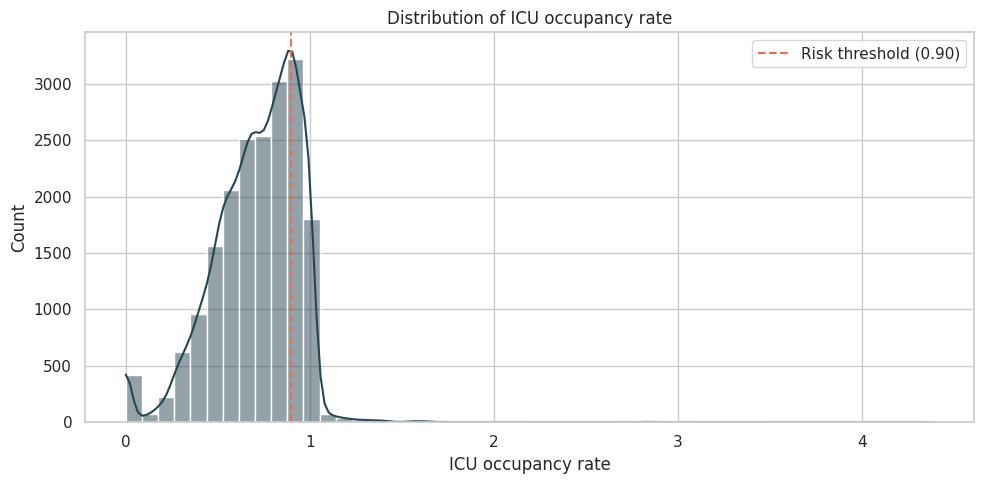

Saved figure: /content/outputs/figures/risk_distribution.png


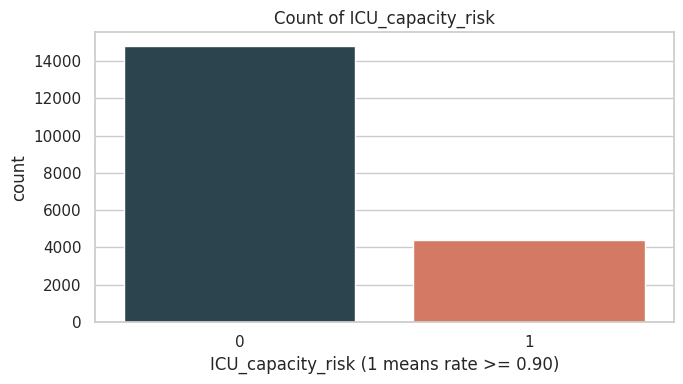

In [ ]:
# 6) Exploratory analysis

# ICU occupancy rate distribution
plt.figure(figsize=(10, 5))
sns.histplot(df["icu_occupancy_rate"], bins=50, kde=True, color="#264653")
plt.axvline(0.9, linestyle="--", color="#e76f51", label="Risk threshold (0.90)")
plt.title("Distribution of ICU occupancy rate")
plt.xlabel("ICU occupancy rate")
plt.legend()
plt.tight_layout()

save_path = FIG_DIR / "icu_distribution.png"
plt.savefig(save_path, bbox_inches="tight", dpi=300)
print(f"Saved figure: {save_path.resolve()}")
plt.show()

# ICU capacity risk distribution
plt.figure(figsize=(7, 4))
sns.countplot(x="ICU_capacity_risk", data=df, palette=["#264653", "#e76f51"])
plt.title("Count of ICU_capacity_risk")
plt.xlabel("ICU_capacity_risk (1 means rate >= 0.90)")
plt.tight_layout()

save_path = FIG_DIR / "risk_distribution.png"
plt.savefig(save_path, bbox_inches="tight", dpi=300)
print(f"Saved figure: {save_path.resolve()}")
plt.show()


## 7. Chi-square test of independence (feature selection)

A chi-square test of independence checks whether two categorical variables are statistically independent. It is applied here between each candidate categorical feature and the target variable `ICU_capacity_risk`.

**Hypotheses for each test:**
- H0: the feature and `ICU_capacity_risk` are independent
- H1: the feature and `ICU_capacity_risk` are dependent

**Decision rule (alpha = 0.05):**
- If p-value < 0.05, reject H0. The feature is statistically associated with the target and is informative for modeling.
- If p-value >= 0.05, fail to reject H0. The feature is not significantly associated with the target.

To extend the test to numeric features, the continuous variables are binned into quartiles before the test. This is a standard approach when applying chi-square to mixed feature types.

The result of each test (chi-square statistic, p-value, degrees of freedom, decision) is saved to `outputs/chi_square_results.csv`.


In [ ]:
# 7) Chi-square test of independence

target_col = "ICU_capacity_risk"
alpha = 0.05

# Categorical features to test
categorical_candidates = ["state", "critical_staffing_shortage_today"]

# Numeric features to bin into quartiles before testing
numeric_candidates = [
    "total_beds",
    "inpatient_beds_used",
    "total_icu_beds",
    "icu_beds_used",
    "bed_occupancy_rate",
]

chi2_records = []

def run_chi2(feature_series, target_series, feature_name):
    contingency = pd.crosstab(feature_series, target_series)
    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        return {
            "feature": feature_name,
            "chi2_statistic": np.nan,
            "p_value": np.nan,
            "degrees_of_freedom": np.nan,
            "decision_at_0.05": "skipped (insufficient categories)",
            "interpretation": "skipped",
        }
    chi2_stat, p_value, dof, _expected = chi2_contingency(contingency)
    if p_value < alpha:
        decision = "reject H0"
        interpretation = "feature is dependent on target (informative)"
    else:
        decision = "fail to reject H0"
        interpretation = "feature is independent of target (not informative)"
    return {
        "feature": feature_name,
        "chi2_statistic": float(chi2_stat),
        "p_value": float(p_value),
        "degrees_of_freedom": int(dof),
        "decision_at_0.05": decision,
        "interpretation": interpretation,
    }

# Categorical features (used as-is)
for feat in categorical_candidates:
    if feat not in df.columns:
        continue
    rec = run_chi2(df[feat], df[target_col], feat)
    chi2_records.append(rec)

# Numeric features (binned into quartiles)
for feat in numeric_candidates:
    if feat not in df.columns:
        continue
    binned = pd.qcut(df[feat], q=4, labels=False, duplicates="drop")
    rec = run_chi2(binned, df[target_col], f"{feat}_quartile_binned")
    chi2_records.append(rec)

chi2_df = pd.DataFrame(chi2_records).sort_values(by="p_value", ascending=True).reset_index(drop=True)

print("Chi-square test of independence results:")
display(chi2_df)

chi2_df.to_csv(CHI2_FILE, index=False)
print(f"\nSaved chi-square results: {CHI2_FILE.resolve()}")

# Summary of which features are informative
informative_features = chi2_df.loc[chi2_df["decision_at_0.05"] == "reject H0", "feature"].tolist()
not_informative = chi2_df.loc[chi2_df["decision_at_0.05"] == "fail to reject H0", "feature"].tolist()

print("\nFeatures statistically associated with the target (reject H0, p < 0.05):")
for f in informative_features:
    print(f"  - {f}")

if not_informative:
    print("\nFeatures not statistically associated with the target (fail to reject H0):")
    for f in not_informative:
        print(f"  - {f}")
else:
    print("\nAll tested features are statistically associated with the target.")


Chi-square test of independence results:


,feature,chi2_statistic,p_value,degrees_of_freedom,decision_at_0.05,interpretation
0,state,1875.645220,0.000000e+00,48.0,reject H0,feature is dependent on target (informative)
1,bed_occupancy_rate_quartile_binned,1356.929845,6.530801e-294,3.0,reject H0,feature is dependent on target (informative)
2,icu_beds_used_quartile_binned,255.012974,5.389528e-55,3.0,reject H0,feature is dependent on target (informative)
3,total_icu_beds_quartile_binned,115.527910,7.086443e-25,3.0,reject H0,feature is dependent on target (informative)
4,inpatient_beds_used_quartile_binned,113.780025,1.685475e-24,3.0,reject H0,feature is dependent on target (informative)
5,total_beds_quartile_binned,63.099806,1.278590e-13,3.0,reject H0,feature is dependent on target (informative)
6,critical_staffing_shortage_today,NaN,NaN,NaN,skipped (insufficient categories),skipped



Saved chi-square results: /content/outputs/chi_square_results.csv

Features statistically associated with the target (reject H0, p < 0.05):
  - state
  - bed_occupancy_rate_quartile_binned
  - icu_beds_used_quartile_binned
  - total_icu_beds_quartile_binned
  - inpatient_beds_used_quartile_binned
  - total_beds_quartile_binned

All tested features are statistically associated with the target.


## 8. Data preparation

- Encode `state` with one-hot encoding
- Convert `collection_week` to a numeric ordinal value
- Build X and y
- Split into 70 percent train and 30 percent test, stratified on the target
- Define separate preprocessing pipelines for linear models (with scaling) and tree-based models (passthrough numerics)


In [ ]:
# 8) Data preparation

# Convert collection_week to datetime, then to ordinal for modeling
collection_week_dt = pd.to_datetime(df["collection_week"], errors="coerce")
df = df.assign(
    collection_week_ordinal=collection_week_dt.map(
        lambda x: x.toordinal() if pd.notna(x) else np.nan
    )
)
df = df.dropna(subset=["collection_week_ordinal"])

feature_cols = [
    "total_beds",
    "inpatient_beds_used",
    "total_icu_beds",
    "icu_beds_used",
    "critical_staffing_shortage_today",
    "state",
    "collection_week_ordinal",
    "icu_occupancy_rate",
    "bed_occupancy_rate",
]

X = df[feature_cols].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train positive rate:", round(float(y_train.mean()), 4),
      "Test positive rate:", round(float(y_test.mean()), 4))

categorical_features = ["state"]
numeric_features = [c for c in feature_cols if c not in categorical_features]

preprocess_for_linear = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("scaler", StandardScaler())]), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop",
)

preprocess_for_trees = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop",
)


Train shape: (13441, 9) Test shape: (5761, 9)
Train positive rate: 0.2286 Test positive rate: 0.2286


## 9. Base models (seven)

Train seven baseline models so the comparison covers a wide range of algorithm families:

1. **Logistic Regression** — linear baseline
2. **Decision Tree** — single-tree baseline
3. **Random Forest** — bagging ensemble of trees
4. **XGBoost** — gradient boosting (extreme gradient boosting)
5. **Gradient Boosting** — sklearn gradient boosting
6. **Extra Trees** — extremely randomized trees
7. **LightGBM** — gradient boosting with histogram-based splits (with KNN fallback)

Each model is wrapped in a pipeline so preprocessing is applied consistently during fit, predict, and cross-validation.


In [ ]:
# 9) Base models (seven)

base_models = {}

base_models["Logistic Regression"] = Pipeline(
    steps=[
        ("preprocess", preprocess_for_linear),
        ("model", LogisticRegression(
            max_iter=500,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
    ]
)

base_models["Decision Tree"] = Pipeline(
    steps=[
        ("preprocess", preprocess_for_trees),
        ("model", DecisionTreeClassifier(
            max_depth=6,
            random_state=RANDOM_STATE,
            class_weight="balanced",
        )),
    ]
)

base_models["Random Forest"] = Pipeline(
    steps=[
        ("preprocess", preprocess_for_trees),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced_subsample",
        )),
    ]
)

base_models["XGBoost"] = Pipeline(
    steps=[
        ("preprocess", preprocess_for_trees),
        ("model", xgb.XGBClassifier(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            eval_metric="logloss",
        )),
    ]
)

base_models["Gradient Boosting"] = Pipeline(
    steps=[
        ("preprocess", preprocess_for_trees),
        ("model", GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=RANDOM_STATE,
        )),
    ]
)

base_models["Extra Trees"] = Pipeline(
    steps=[
        ("preprocess", preprocess_for_trees),
        ("model", ExtraTreesClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced",
        )),
    ]
)

if LIGHTGBM_AVAILABLE:
    base_models["LightGBM"] = Pipeline(
        steps=[
            ("preprocess", preprocess_for_trees),
            ("model", LGBMClassifier(
                n_estimators=400,
                learning_rate=0.05,
                max_depth=-1,
                num_leaves=31,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                class_weight="balanced",
                verbose=-1,
            )),
        ]
    )
else:
    base_models["KNN"] = Pipeline(
        steps=[
            ("preprocess", preprocess_for_linear),
            ("model", KNeighborsClassifier(n_neighbors=15, n_jobs=-1)),
        ]
    )

print(f"Configured {len(base_models)} base models:")
for name in base_models:
    print(f"  - {name}")


Configured 7 base models:
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - XGBoost
  - Gradient Boosting
  - Extra Trees
  - LightGBM


## 10. Stratified k-fold cross-validation

Each base model is evaluated using **stratified k-fold cross-validation** with five folds. Stratification preserves the class ratio in every fold, which matters here because the positive class (`ICU_capacity_risk = 1`) is the minority class.

Three scoring metrics are reported per model: accuracy, F1 score, and ROC-AUC. The F1 score is the most informative metric for the imbalanced setting because it balances precision and recall on the positive class.


In [ ]:
# 10) Stratified k-fold cross-validation

skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_records = []

for name, pipe in base_models.items():
    print("=" * 80)
    print(f"Cross-validating: {name}")

    acc_scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring="accuracy", n_jobs=-1)
    f1_scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring="f1", n_jobs=-1)
    auc_scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring="roc_auc", n_jobs=-1)

    print(f"  Accuracy: mean={acc_scores.mean():.4f}, std={acc_scores.std():.4f}")
    print(f"  F1:       mean={f1_scores.mean():.4f}, std={f1_scores.std():.4f}")
    print(f"  ROC-AUC:  mean={auc_scores.mean():.4f}, std={auc_scores.std():.4f}")

    cv_records.append({
        "model": name,
        "cv_accuracy_mean": acc_scores.mean(),
        "cv_accuracy_std": acc_scores.std(),
        "cv_f1_mean": f1_scores.mean(),
        "cv_f1_std": f1_scores.std(),
        "cv_auc_mean": auc_scores.mean(),
        "cv_auc_std": auc_scores.std(),
    })

cv_df = pd.DataFrame(cv_records).sort_values(by="cv_f1_mean", ascending=False).reset_index(drop=True)
print("\nCross-validation summary (sorted by mean F1):")
display(cv_df)

cv_df.to_csv(CV_FILE, index=False)
print(f"\nSaved cross-validation results: {CV_FILE.resolve()}")


Cross-validating: Logistic Regression
  Accuracy: mean=0.9794, std=0.0037
  F1:       mean=0.9569, std=0.0074
  ROC-AUC:  mean=0.9998, std=0.0001
Cross-validating: Decision Tree
  Accuracy: mean=0.9993, std=0.0004
  F1:       mean=0.9985, std=0.0008
  ROC-AUC:  mean=0.9997, std=0.0004
Cross-validating: Random Forest
  Accuracy: mean=0.9990, std=0.0006
  F1:       mean=0.9979, std=0.0014
  ROC-AUC:  mean=1.0000, std=0.0000
Cross-validating: XGBoost
  Accuracy: mean=0.9991, std=0.0006
  F1:       mean=0.9981, std=0.0013
  ROC-AUC:  mean=1.0000, std=0.0000
Cross-validating: Gradient Boosting
  Accuracy: mean=0.9996, std=0.0002
  F1:       mean=0.9992, std=0.0005
  ROC-AUC:  mean=1.0000, std=0.0000
Cross-validating: Extra Trees
  Accuracy: mean=0.9710, std=0.0023
  F1:       mean=0.9356, std=0.0054
  ROC-AUC:  mean=0.9961, std=0.0006
Cross-validating: LightGBM
  Accuracy: mean=0.9993, std=0.0003
  F1:       mean=0.9985, std=0.0006
  ROC-AUC:  mean=1.0000, std=0.0000

Cross-validation summa

,model,cv_accuracy_mean,cv_accuracy_std,cv_f1_mean,cv_f1_std,cv_auc_mean,cv_auc_std
0,Gradient Boosting,0.999628,0.000235,0.999187,0.000513,0.999998,0.000001
1,LightGBM,0.999330,0.000278,0.998538,0.000607,0.999998,0.000001
2,Decision Tree,0.999330,0.000364,0.998537,0.000797,0.999688,0.000416
3,XGBoost,0.999107,0.000604,0.998052,0.001318,0.999996,0.000005
4,Random Forest,0.999033,0.000649,0.997891,0.001413,0.999987,0.000009
5,Logistic Regression,0.979392,0.003715,0.956930,0.007447,0.999794,0.000129
6,Extra Trees,0.970984,0.002330,0.935641,0.005429,0.996101,0.000597



Saved cross-validation results: /content/outputs/cross_validation_results.csv


## 11. Stacking ensemble

A stacking ensemble combines the predictions of several base learners using a meta-learner that is trained on out-of-fold base predictions. This often improves performance over any single base model when the base learners make different kinds of errors.

**Configuration used here:**
- Base learners: Random Forest, XGBoost, Gradient Boosting, Extra Trees, and (LightGBM or KNN, depending on environment)
- Meta-learner: Logistic Regression
- Internal cross-validation: stratified 5-fold (to generate out-of-fold predictions for the meta-learner)

The stacking model is treated as an additional model in the comparison and is also evaluated using the same stratified k-fold cross-validation as the base learners.


In [ ]:
# 11) Stacking ensemble

# Use a subset of strong, diverse base learners as stacking inputs.
# These are bare estimators (not pipelines) because StackingClassifier expects
# estimators it can clone and refit; we wrap the whole stack in a pipeline so
# preprocessing is still applied once at the top.

stacking_estimators = [
    ("rf", RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample",
    )),
    ("xgb", xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric="logloss",
    )),
    ("gbm", GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=4,
        random_state=RANDOM_STATE,
    )),
    ("et", ExtraTreesClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced",
    )),
]

if LIGHTGBM_AVAILABLE:
    stacking_estimators.append((
        "lgbm",
        LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced",
            verbose=-1,
        ),
    ))

stacking_meta = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)

stacking_clf = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=stacking_meta,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
    passthrough=False,
)

stacking_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess_for_trees),
        ("model", stacking_clf),
    ]
)

print("Stacking base learners:")
for name, _ in stacking_estimators:
    print(f"  - {name}")
print(f"Stacking meta-learner: Logistic Regression")
print(f"Internal CV folds for out-of-fold predictions: 5")

# Cross-validate the stacking ensemble on the training set
print("\nCross-validating: Stacking Ensemble")
stack_acc = cross_val_score(stacking_pipeline, X_train, y_train, cv=skf, scoring="accuracy", n_jobs=-1)
stack_f1 = cross_val_score(stacking_pipeline, X_train, y_train, cv=skf, scoring="f1", n_jobs=-1)
stack_auc = cross_val_score(stacking_pipeline, X_train, y_train, cv=skf, scoring="roc_auc", n_jobs=-1)

print(f"  Accuracy: mean={stack_acc.mean():.4f}, std={stack_acc.std():.4f}")
print(f"  F1:       mean={stack_f1.mean():.4f}, std={stack_f1.std():.4f}")
print(f"  ROC-AUC:  mean={stack_auc.mean():.4f}, std={stack_auc.std():.4f}")

# Append stacking results to the CV summary
cv_records.append({
    "model": "Stacking Ensemble",
    "cv_accuracy_mean": stack_acc.mean(),
    "cv_accuracy_std": stack_acc.std(),
    "cv_f1_mean": stack_f1.mean(),
    "cv_f1_std": stack_f1.std(),
    "cv_auc_mean": stack_auc.mean(),
    "cv_auc_std": stack_auc.std(),
})

cv_df = pd.DataFrame(cv_records).sort_values(by="cv_f1_mean", ascending=False).reset_index(drop=True)
print("\nUpdated cross-validation summary (sorted by mean F1):")
display(cv_df)

cv_df.to_csv(CV_FILE, index=False)
print(f"\nUpdated cross-validation results: {CV_FILE.resolve()}")

# Add stacking to the model dictionary used for held-out evaluation
all_models = dict(base_models)
all_models["Stacking Ensemble"] = stacking_pipeline


Stacking base learners:
  - rf
  - xgb
  - gbm
  - et
  - lgbm
Stacking meta-learner: Logistic Regression
Internal CV folds for out-of-fold predictions: 5

Cross-validating: Stacking Ensemble
  Accuracy: mean=0.9994, std=0.0004
  F1:       mean=0.9987, std=0.0010
  ROC-AUC:  mean=1.0000, std=0.0000

Updated cross-validation summary (sorted by mean F1):


,model,cv_accuracy_mean,cv_accuracy_std,cv_f1_mean,cv_f1_std,cv_auc_mean,cv_auc_std
0,Gradient Boosting,0.999628,0.000235,0.999187,0.000513,0.999998,0.000001
1,Stacking Ensemble,0.999405,0.000446,0.998701,0.000974,0.999991,0.000013
2,LightGBM,0.999330,0.000278,0.998538,0.000607,0.999998,0.000001
3,Decision Tree,0.999330,0.000364,0.998537,0.000797,0.999688,0.000416
4,XGBoost,0.999107,0.000604,0.998052,0.001318,0.999996,0.000005
5,Random Forest,0.999033,0.000649,0.997891,0.001413,0.999987,0.000009
6,Logistic Regression,0.979392,0.003715,0.956930,0.007447,0.999794,0.000129
7,Extra Trees,0.970984,0.002330,0.935641,0.005429,0.996101,0.000597



Updated cross-validation results: /content/outputs/cross_validation_results.csv


## 12. Evaluation on held-out test set

After cross-validation, each model is fit once on the full training set and evaluated on the held-out 30 percent test set. This gives a final, independent estimate of generalization performance.

Reported per model:
- Accuracy, precision, recall, F1, ROC-AUC
- Classification report
- Confusion matrix (saved as a figure)
- Fitted model serialized to disk


Logistic Regression
Saved model: /content/outputs/models/logistic_regression_model.pkl
Accuracy:  0.9837
Precision: 0.9334
Recall:    1.0000
F1:        0.9655
ROC-AUC:   0.9999

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9788    0.9893      4444
           1     0.9334    1.0000    0.9655      1317

    accuracy                         0.9837      5761
   macro avg     0.9667    0.9894    0.9774      5761
weighted avg     0.9848    0.9837    0.9839      5761

Saved figure: /content/outputs/figures/confusion_matrix_-_logistic_regression.png


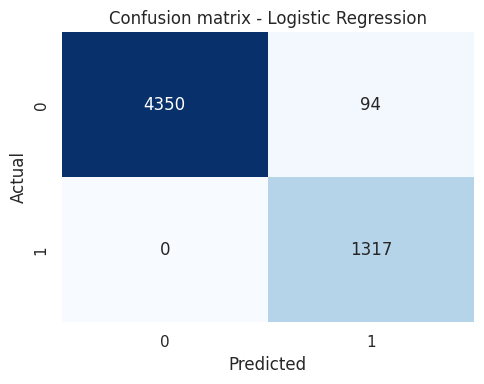

Decision Tree
Saved model: /content/outputs/models/decision_tree_model.pkl
Accuracy:  0.9990
Precision: 0.9962
Recall:    0.9992
F1:        0.9977
ROC-AUC:   0.9996

Classification report:
              precision    recall  f1-score   support

           0     0.9998    0.9989    0.9993      4444
           1     0.9962    0.9992    0.9977      1317

    accuracy                         0.9990      5761
   macro avg     0.9980    0.9991    0.9985      5761
weighted avg     0.9990    0.9990    0.9990      5761

Saved figure: /content/outputs/figures/confusion_matrix_-_decision_tree.png


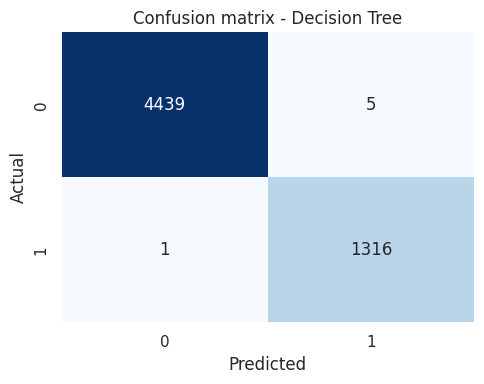

Random Forest
Saved model: /content/outputs/models/random_forest_model.pkl
Accuracy:  0.9993
Precision: 0.9970
Recall:    1.0000
F1:        0.9985
ROC-AUC:   1.0000

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9991    0.9995      4444
           1     0.9970    1.0000    0.9985      1317

    accuracy                         0.9993      5761
   macro avg     0.9985    0.9995    0.9990      5761
weighted avg     0.9993    0.9993    0.9993      5761

Saved figure: /content/outputs/figures/confusion_matrix_-_random_forest.png


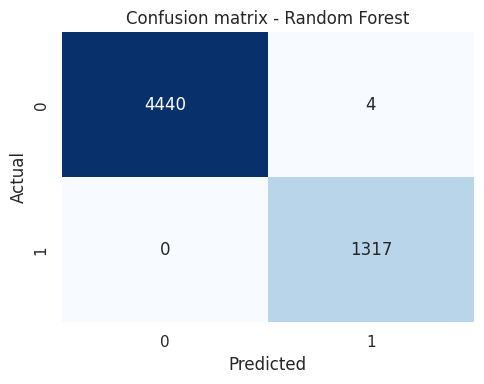

XGBoost
Saved model: /content/outputs/models/xgboost_model.pkl
Accuracy:  0.9995
Precision: 0.9985
Recall:    0.9992
F1:        0.9989
ROC-AUC:   1.0000

Classification report:
              precision    recall  f1-score   support

           0     0.9998    0.9995    0.9997      4444
           1     0.9985    0.9992    0.9989      1317

    accuracy                         0.9995      5761
   macro avg     0.9991    0.9994    0.9993      5761
weighted avg     0.9995    0.9995    0.9995      5761

Saved figure: /content/outputs/figures/confusion_matrix_-_xgboost.png


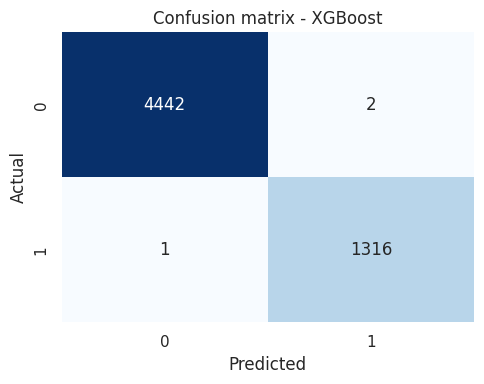

Gradient Boosting
Saved model: /content/outputs/models/gradient_boosting_model.pkl
Accuracy:  0.9997
Precision: 0.9992
Recall:    0.9992
F1:        0.9992
ROC-AUC:   1.0000

Classification report:
              precision    recall  f1-score   support

           0     0.9998    0.9998    0.9998      4444
           1     0.9992    0.9992    0.9992      1317

    accuracy                         0.9997      5761
   macro avg     0.9995    0.9995    0.9995      5761
weighted avg     0.9997    0.9997    0.9997      5761

Saved figure: /content/outputs/figures/confusion_matrix_-_gradient_boosting.png


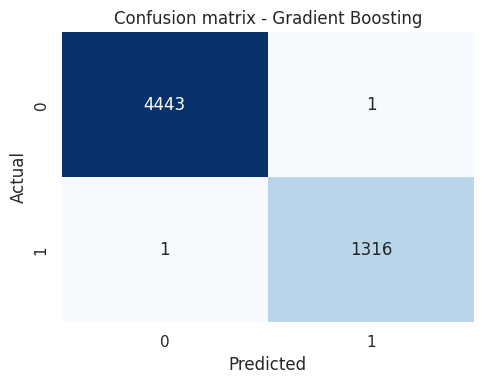

Extra Trees
Saved model: /content/outputs/models/extra_trees_model.pkl
Accuracy:  0.9769
Precision: 0.9647
Recall:    0.9332
F1:        0.9487
ROC-AUC:   0.9977

Classification report:
              precision    recall  f1-score   support

           0     0.9804    0.9899    0.9851      4444
           1     0.9647    0.9332    0.9487      1317

    accuracy                         0.9769      5761
   macro avg     0.9725    0.9615    0.9669      5761
weighted avg     0.9768    0.9769    0.9768      5761

Saved figure: /content/outputs/figures/confusion_matrix_-_extra_trees.png


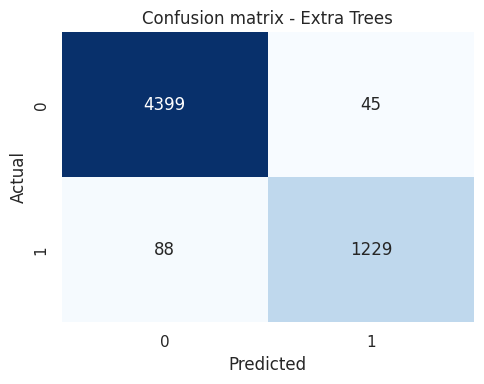

LightGBM
Saved model: /content/outputs/models/lightgbm_model.pkl
Accuracy:  0.9997
Precision: 0.9992
Recall:    0.9992
F1:        0.9992
ROC-AUC:   1.0000

Classification report:
              precision    recall  f1-score   support

           0     0.9998    0.9998    0.9998      4444
           1     0.9992    0.9992    0.9992      1317

    accuracy                         0.9997      5761
   macro avg     0.9995    0.9995    0.9995      5761
weighted avg     0.9997    0.9997    0.9997      5761

Saved figure: /content/outputs/figures/confusion_matrix_-_lightgbm.png


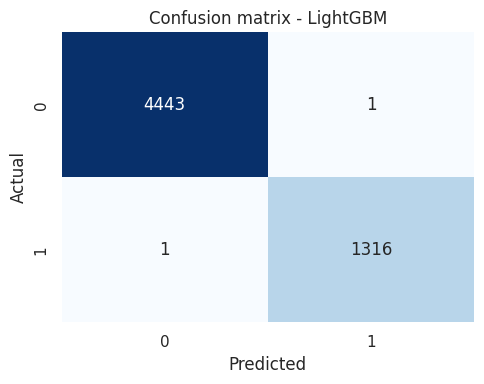

Stacking Ensemble
Saved model: /content/outputs/models/stacking_ensemble_model.pkl
Accuracy:  0.9997
Precision: 0.9992
Recall:    0.9992
F1:        0.9992
ROC-AUC:   1.0000

Classification report:
              precision    recall  f1-score   support

           0     0.9998    0.9998    0.9998      4444
           1     0.9992    0.9992    0.9992      1317

    accuracy                         0.9997      5761
   macro avg     0.9995    0.9995    0.9995      5761
weighted avg     0.9997    0.9997    0.9997      5761

Saved figure: /content/outputs/figures/confusion_matrix_-_stacking_ensemble.png


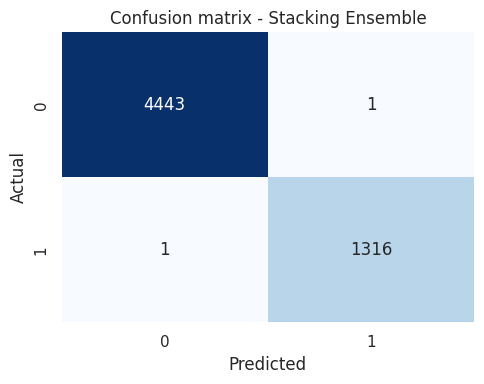

In [ ]:
# 12) Evaluation on held-out test set

def plot_confusion(cm, title):
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()

    slug = (
        title.replace("—", "-")
        .replace(" ", "_")
        .replace("/", "_")
        .replace("__", "_")
        .lower()
    )
    save_path = FIG_DIR / f"{slug}.png"
    plt.savefig(save_path, bbox_inches="tight", dpi=300)
    print(f"Saved figure: {save_path.resolve()}")
    plt.show()

results = []
trained_models = {}

for name, pipe in all_models.items():
    print("=" * 80)
    print(name)

    pipe.fit(X_train, y_train)
    trained_models[name] = pipe

    # Save fitted model
    safe_name = name.replace(" ", "_").lower()
    model_path = MODEL_DIR / f"{safe_name}_model.pkl"
    joblib.dump(pipe, model_path)
    print(f"Saved model: {model_path.resolve()}")

    y_pred = pipe.predict(X_test)
    try:
        y_proba = pipe.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    except Exception:
        auc = np.nan

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1:        {f1:.4f}")
    print(f"ROC-AUC:   {auc:.4f}")
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred)
    plot_confusion(cm, f"Confusion matrix - {name}")

    results.append({
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": auc,
    })


## 13. Comparison table

Side-by-side comparison of all models on the held-out test set, sorted by F1 score.


,model,accuracy,precision,recall,f1,roc_auc
0,LightGBM,0.999653,0.999241,0.999241,0.999241,1.000000
1,Stacking Ensemble,0.999653,0.999241,0.999241,0.999241,0.999999
2,Gradient Boosting,0.999653,0.999241,0.999241,0.999241,0.999999
3,XGBoost,0.999479,0.998483,0.999241,0.998861,0.999998
4,Random Forest,0.999306,0.996972,1.000000,0.998484,0.999997
5,Decision Tree,0.998959,0.996215,0.999241,0.997726,0.999614
6,Logistic Regression,0.983683,0.933381,1.000000,0.965543,0.999906
7,Extra Trees,0.976914,0.964678,0.933181,0.948668,0.997736


Saved comparison table: /content/outputs/model_comparison.csv
Saved figure: /content/outputs/figures/model_f1_comparison.png


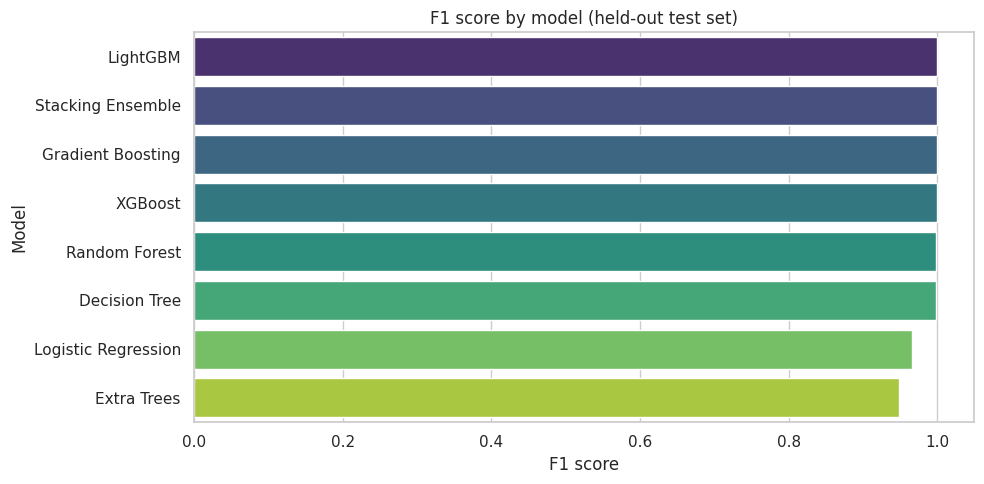

In [ ]:
# 13) Comparison table

comparison_df = pd.DataFrame(results).sort_values(by="f1", ascending=False).reset_index(drop=True)
display(comparison_df)

comparison_df.to_csv(RESULTS_FILE, index=False)
print(f"Saved comparison table: {RESULTS_FILE.resolve()}")

# Bar chart of F1 scores
plt.figure(figsize=(10, 5))
sns.barplot(
    data=comparison_df,
    x="f1",
    y="model",
    palette="viridis",
)
plt.title("F1 score by model (held-out test set)")
plt.xlabel("F1 score")
plt.ylabel("Model")
plt.tight_layout()

save_path = FIG_DIR / "model_f1_comparison.png"
plt.savefig(save_path, bbox_inches="tight", dpi=300)
print(f"Saved figure: {save_path.resolve()}")
plt.show()


## 14. Explainability with SHAP

SHAP (SHapley Additive exPlanations) is applied to the fitted XGBoost model to identify which features drive the predictions. This addresses the **transparency** concern from the introduction: a model used in resource decisions should be auditable.


Saved figure: /content/outputs/figures/shap_summary.png


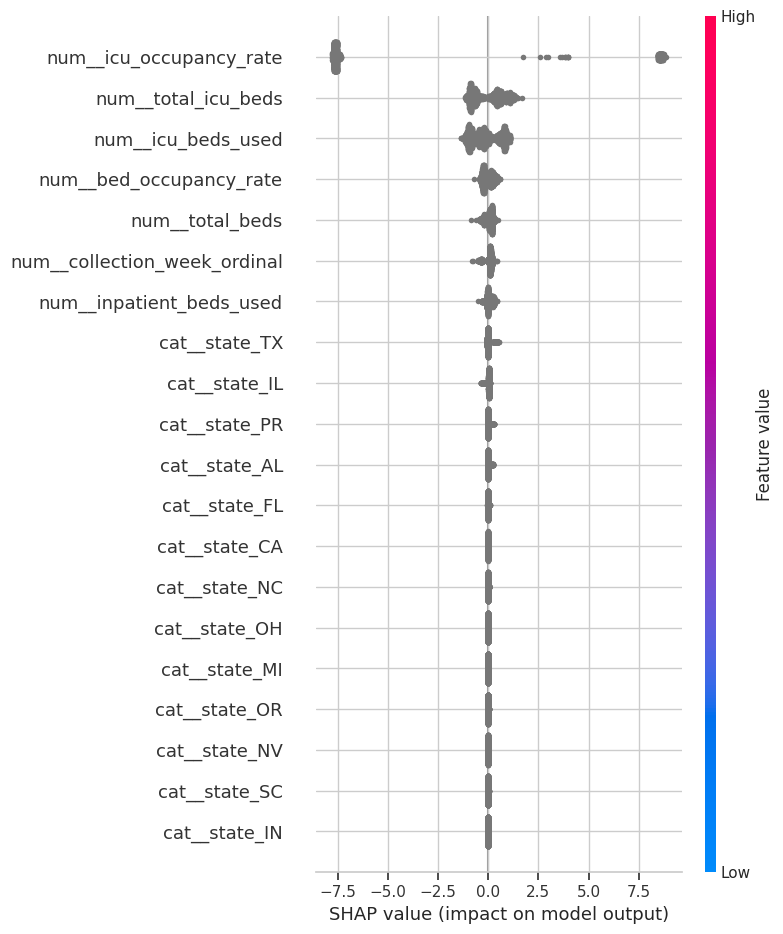

In [ ]:
# 14) SHAP explainability (XGBoost)

xgb_pipe = trained_models.get("XGBoost")
if xgb_pipe is None:
    raise ValueError("XGBoost model not found in trained_models. Ensure section 12 ran.")

pre = xgb_pipe.named_steps["preprocess"]
mdl = xgb_pipe.named_steps["model"]

X_shap = X_test.sample(n=min(2000, len(X_test)), random_state=RANDOM_STATE)
X_shap_trans = pre.transform(X_shap)

try:
    feature_names = pre.get_feature_names_out()
except Exception:
    feature_names = [f"f{i}" for i in range(getattr(X_shap_trans, "shape", [0, 0])[1])]

explainer = shap.TreeExplainer(mdl)
shap_values = explainer.shap_values(X_shap_trans)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap_trans, feature_names=feature_names, show=False)
plt.tight_layout()

save_path = FIG_DIR / "shap_summary.png"
plt.savefig(save_path, bbox_inches="tight", dpi=300)
print(f"Saved figure: {save_path.resolve()}")
plt.show()


## 15. Saved artifact verification

Final listing of everything written to disk so the outputs can be cited in the report.


In [ ]:
# 15) Final verification: list saved artifacts

print("Saved figure files:")
for f in sorted(FIG_DIR.glob("*")):
    print(f"  - {f.name}")

print("\nSaved model files:")
for f in sorted(MODEL_DIR.glob("*")):
    print(f"  - {f.name}")

print("\nResult tables:")
print(f"  - Comparison file exists: {RESULTS_FILE.exists()} ({RESULTS_FILE.resolve()})")
print(f"  - Chi-square file exists: {CHI2_FILE.exists()} ({CHI2_FILE.resolve()})")
print(f"  - Cross-validation file exists: {CV_FILE.exists()} ({CV_FILE.resolve()})")


Saved figure files:
  - confusion_matrix_-_decision_tree.png
  - confusion_matrix_-_extra_trees.png
  - confusion_matrix_-_gradient_boosting.png
  - confusion_matrix_-_lightgbm.png
  - confusion_matrix_-_logistic_regression.png
  - confusion_matrix_-_random_forest.png
  - confusion_matrix_-_stacking_ensemble.png
  - confusion_matrix_-_xgboost.png
  - icu_distribution.png
  - model_f1_comparison.png
  - risk_distribution.png
  - shap_summary.png

Saved model files:
  - decision_tree_model.pkl
  - extra_trees_model.pkl
  - gradient_boosting_model.pkl
  - lightgbm_model.pkl
  - logistic_regression_model.pkl
  - random_forest_model.pkl
  - stacking_ensemble_model.pkl
  - xgboost_model.pkl

Result tables:
  - Comparison file exists: True (/content/outputs/model_comparison.csv)
  - Chi-square file exists: True (/content/outputs/chi_square_results.csv)
  - Cross-validation file exists: True (/content/outputs/cross_validation_results.csv)
